<a href="https://colab.research.google.com/github/majorluvale/hpc-data-analysis/blob/main/Analyse_HPC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import json
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings


#Import the hpc_data function
from hpc_data import getPlanData

import warnings
warnings.filterwarnings("ignore")

## Global Cluster IDs Reference

We'll use the function `getPlanData` to get HPC data.  It takes two inputs: `Year` and `GlobalClusterId`.

---

### Cluster List

| *Global Cluster Id* | *Name*                                      | *Code* | *Type* |
|:------:|-----------------------------------------------|:--------:|:--------:|
| `1`      | Camp Coordination / Management               | `CCM`    | global   |
| `2`      | Early Recovery                               | `ERY`    | global   |
| `3`      | Education                                    | `EDU`    | global   |
| `4`      | Emergency Shelter and NFI                    | `SHL`    | global   |
| `5`      | Emergency Telecommunications                 | `TEL`    | global   |
| `6`      | Food Security                                | `FSC`    | global   |
| `7`      | Health                                       | `HEA`    | global   |
| `8`      | Logistics                                    | `LOG`    | global   |
| `9`      | Nutrition                                    | `NUT`    | global   |
| `10`     | Protection                                   | `PRO`    | global   |
| `11`    | Water Sanitation Hygiene                     | `WSH`    | global   |
| `12`     | Protection - Child Protection                | `PRO-CPN`| aor      |
| `13`     | Protection - Gender-Based Violence           | `PRO-GBV`| aor      |
| `14`     | Protection - Housing, Land and Property      | `PRO-HLP`| aor      |
| `15`     | Protection - Mine Action                     | `PRO-MIN`| aor      |
| `16`     | Multipurpose Cash                            | `MPC`    | global   |
| `26479`  | Multi-sector                                 | `MS`     | custom   |
| `26480`  | Coordination and support services            | `CSS`    | custom   |
| `26481`  | Other                                        | `OTH`    | custom   |
| `26512`  | Agriculture                                  | `AGR`    | custom   |
| `26513`  | COVID-19                                     | `COV19`  | custom   |
| `26546`  | Protection - Human Trafficking & Smuggling   | `PRO-HTS`| aor      |

---

*Tip: Use the `GlobalClusterId` values above when calling `getPlanData`.*

In [2]:
PLAN_YEAR = 2025 #@param {type:"slider", min:2021, max:2025, step:1}

#Example extract for GBV
GLOBAL_CLUSTER_ID = 13

## Get Data

In [3]:
df = getPlanData(PLAN_YEAR, GLOBAL_CLUSTER_ID)
df.head()

Cluster code: PRO-GBV, Cluster name: Protection - Gender-Based Violence
All done!


,planId,planYear,countryName,countryISO3,planName,planType,isReleased,planCostingType,peopleInNeed,peopleTargeted,peopleReached,requiredFunds,fundedAmount,cashTransferFunding
0,1208,2025,Colombia,COL,Colombia Necesidades Humanitarias y Plan de Re...,Humanitarian needs and response plan,True,Projects costed requirements,3281409.0,362555.0,0.0,15895901.0,2927168,0.0
1,1211,2025,Afghanistan,AFG,Afghanistan Situation Regional Refugee Respons...,Regional response plan,True,Projects costed requirements,0.0,0.0,0.0,30788836.0,784236,9661.0
2,1212,2025,Bangladesh,BGD,Rohingya Humanitarian Crisis Joint Response Pl...,Regional response plan,True,Projects costed requirements,1118437.0,843603.0,390504.0,27439885.0,4116609,32035.0
3,1213,2025,Democratic Republic of the Congo,COD,Democratic Republic of the Congo Regional Refu...,Regional response plan,True,Projects costed requirements,0.0,0.0,0.0,27557386.0,3484202,0.0
4,1215,2025,South Sudan,SSD,South Sudan Regional Refugee Response Plan 2025,Regional response plan,True,Projects costed requirements,0.0,0.0,0.0,22966491.0,2962627,0.0


## Data Exploration

In [4]:
#Number of Rows and Columns
df.shape

(42, 14)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   planId               42 non-null     object 
 1   planYear             42 non-null     str    
 2   countryName          42 non-null     str    
 3   countryISO3          42 non-null     str    
 4   planName             42 non-null     str    
 5   planType             42 non-null     str    
 6   isReleased           42 non-null     bool   
 7   planCostingType      42 non-null     str    
 8   peopleInNeed         42 non-null     float64
 9   peopleTargeted       42 non-null     float64
 10  peopleReached        42 non-null     float64
 11  requiredFunds        42 non-null     float64
 12  fundedAmount         42 non-null     int64  
 13  cashTransferFunding  42 non-null     float64
dtypes: bool(1), float64(5), int64(1), object(1), str(6)
memory usage: 4.4+ KB


In [6]:
#selection of qualitative variables
cat_data = df.select_dtypes(include=['object', 'str'])
cat_data.head()

,planId,planYear,countryName,countryISO3,planName,planType,planCostingType
0,1208,2025,Colombia,COL,Colombia Necesidades Humanitarias y Plan de Re...,Humanitarian needs and response plan,Projects costed requirements
1,1211,2025,Afghanistan,AFG,Afghanistan Situation Regional Refugee Respons...,Regional response plan,Projects costed requirements
2,1212,2025,Bangladesh,BGD,Rohingya Humanitarian Crisis Joint Response Pl...,Regional response plan,Projects costed requirements
3,1213,2025,Democratic Republic of the Congo,COD,Democratic Republic of the Congo Regional Refu...,Regional response plan,Projects costed requirements
4,1215,2025,South Sudan,SSD,South Sudan Regional Refugee Response Plan 2025,Regional response plan,Projects costed requirements


In [7]:
#selection of quantitative variables
quant_data = df.select_dtypes(include='number')
quant_data.head()

,peopleInNeed,peopleTargeted,peopleReached,requiredFunds,fundedAmount,cashTransferFunding
0,3281409.0,362555.0,0.0,15895901.0,2927168,0.0
1,0.0,0.0,0.0,30788836.0,784236,9661.0
2,1118437.0,843603.0,390504.0,27439885.0,4116609,32035.0
3,0.0,0.0,0.0,27557386.0,3484202,0.0
4,0.0,0.0,0.0,22966491.0,2962627,0.0


#### Describe categorical variables

In [8]:
cat_data.describe()

,planId,planYear,countryName,countryISO3,planName,planType,planCostingType
count,42,42,42,42,42,42,42
unique,42,1,31,31,42,5,3
top,1208,2025,Mozambique,MOZ,Colombia Necesidades Humanitarias y Plan de Re...,Humanitarian needs and response plan,Unit-Based costed requirements - without projects
freq,1,42,3,3,1,21,19


In [9]:
cat_data['planType'].value_counts()

planType
Humanitarian needs and response plan    21
Regional response plan                   8
Flash appeal                             8
Other (included in GHO)                  3
Humanitarian response plan               2
Name: count, dtype: int64

In [10]:
val = cat_data['planType'].value_counts().to_frame('count').reset_index(names="planType")
val

,planType,count
0,Humanitarian needs and response plan,21
1,Regional response plan,8
2,Flash appeal,8
3,Other (included in GHO),3
4,Humanitarian response plan,2


In [11]:
def barplot_func(col):
    #Plan Type
    val = cat_data[col].value_counts().to_frame('count').reset_index(names=col)
    fig = px.bar(val, x = col, y='count', text_auto=True, title=f"Plans by {col}", labels={"count": "Number of plans"})
    fig.show()

#### Visualize categorical variables

In [12]:
for col in ['countryName', 'planType', 'planCostingType']:
    barplot_func(col)

#### Describe quantitative variables

In [13]:
quant_data.describe()

,peopleInNeed,peopleTargeted,peopleReached,requiredFunds,fundedAmount,cashTransferFunding
count,4.200000e+01,4.200000e+01,4.200000e+01,4.200000e+01,4.200000e+01,4.200000e+01
mean,2.183098e+06,6.245217e+05,1.404836e+05,2.658587e+07,6.802331e+06,1.015643e+05
std,3.298949e+06,7.307513e+05,3.901189e+05,2.382078e+07,8.913633e+06,2.330558e+05
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,1.912500e+04,0.000000e+00,6.435253e+06,6.155610e+05,0.000000e+00
50%,1.014284e+06,3.866335e+05,0.000000e+00,2.221517e+07,3.576976e+06,0.000000e+00
75%,2.379852e+06,9.278762e+05,5.812350e+04,3.509425e+07,9.955279e+06,9.524100e+04
max,1.417329e+07,3.155022e+06,2.353490e+06,8.854222e+07,3.346233e+07,1.116621e+06


#### Visualize quantitative variables

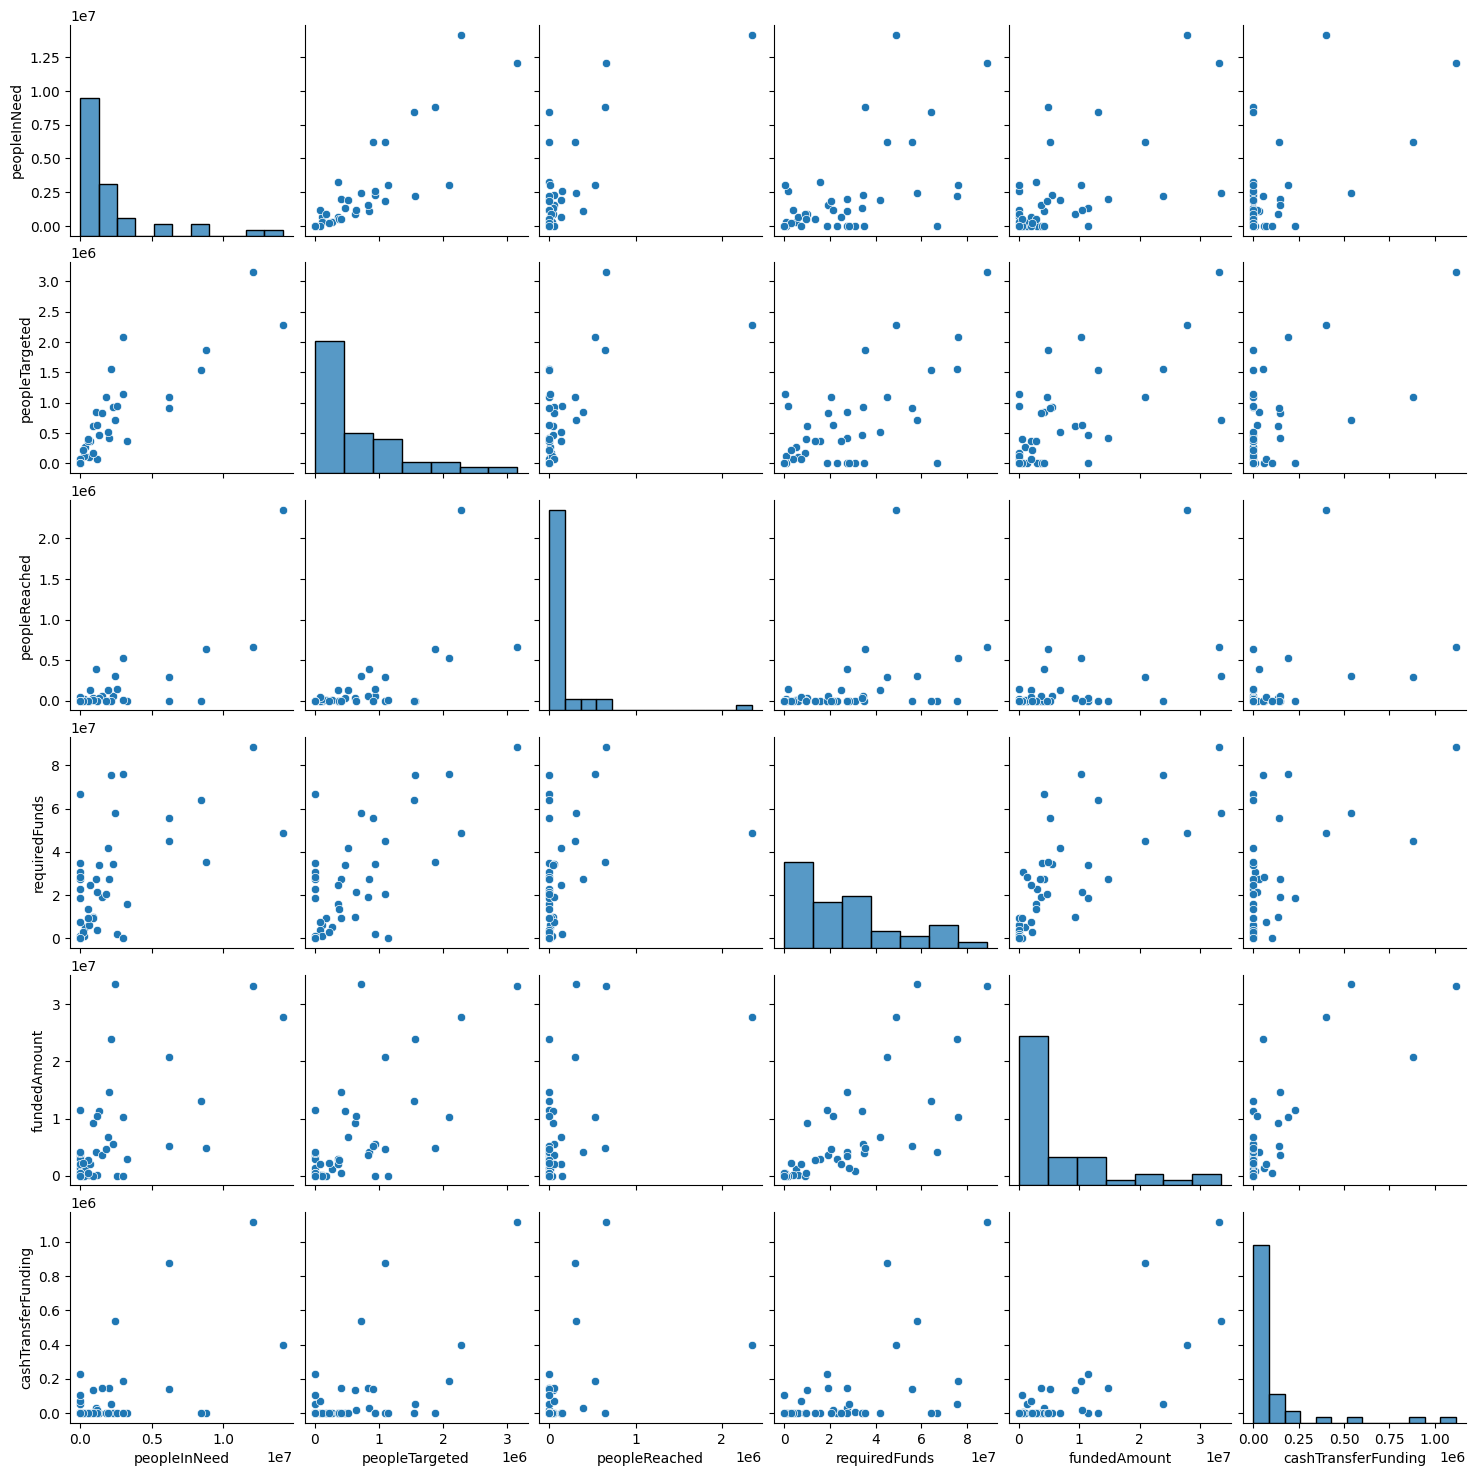

In [14]:
sns.pairplot(quant_data)
plt.show()

In [15]:
#boxplots
import plotly.express as px
def boxplot_func(col):
    fig = px.box(df,x = col)
    fig.show()

In [16]:
#boxplot_func
for col in quant_data.columns:
    boxplot_func(col)

##### Correlation Matrix

In [17]:
# Correlation matrix
quant_data.corr()

,peopleInNeed,peopleTargeted,peopleReached,requiredFunds,fundedAmount,cashTransferFunding
peopleInNeed,1.000000,0.859031,0.753554,0.568482,0.638746,0.598049
peopleTargeted,0.859031,1.000000,0.629845,0.658431,0.661387,0.578973
peopleReached,0.753554,0.629845,1.000000,0.356159,0.533398,0.437880
requiredFunds,0.568482,0.658431,0.356159,1.000000,0.726798,0.519675
fundedAmount,0.638746,0.661387,0.533398,0.726798,1.000000,0.780734
cashTransferFunding,0.598049,0.578973,0.437880,0.519675,0.780734,1.000000


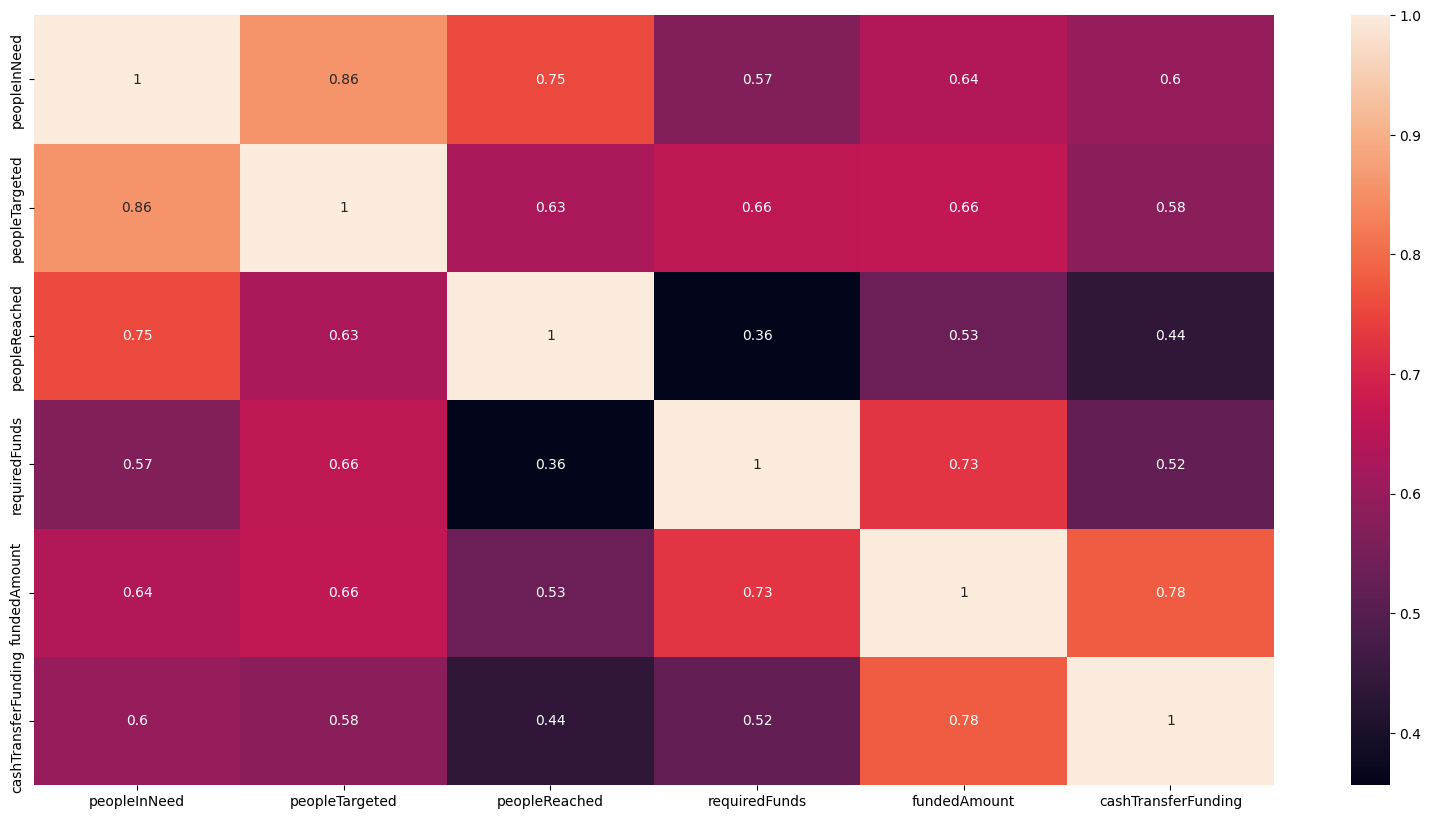

In [18]:
# Visualize correlation matrix
plt.figure(figsize = (20, 10))
sns.heatmap(quant_data.corr(), annot = True)
plt.show()